In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
iris = load_iris()
x = iris.data
y = iris.target
target_names = iris.target_names

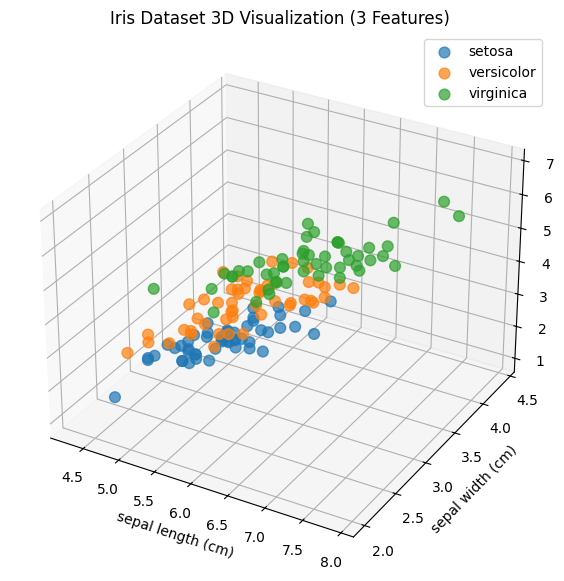

In [103]:
# Üç özellik seçiyoruz (örnek: sepal length, sepal width, petal length)
x1, x2, x3 = 0, 1, 2  # sütun indexleri

# 3D çizim
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for target in np.unique(y):
    ax.scatter(
        x[y == target, x1],
        x[y == target, x2],
        x[y == target, x3],
        label=target_names[target],
        s=60,
        alpha=0.7
    )

ax.set_xlabel(iris.feature_names[x1])
ax.set_ylabel(iris.feature_names[x2])
ax.set_zlabel(iris.feature_names[x3])
ax.set_title("Iris Dataset 3D Visualization (3 Features)")
ax.legend()
plt.show()

In [104]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train , y_test = train_test_split(x, y, test_size=0.33, random_state=0)

# y_train'i 1D bir diziye dönüştürmek için ravel() fonksiyonunu kullanabilirsiniz
y_train = np.ravel(y_train)
print(y_train)

[1 2 1 1 2 2 2 2 1 2 1 0 2 1 1 1 1 2 0 0 2 1 0 0 1 0 2 1 0 1 2 1 0 2 2 2 2
 0 0 2 2 0 2 0 2 2 0 0 2 0 0 0 1 2 2 0 0 0 1 1 0 0 1 0 2 1 2 1 0 2 0 2 0 0
 2 0 2 1 1 1 2 2 1 1 0 1 2 2 0 1 1 1 1 0 0 0 2 1 2 0]


In [105]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [106]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test.ravel())

In [107]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.svm import SVC

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='linear', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True),
    "SVM (Polynomial)": SVC(kernel='poly', degree=3, probability=True),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42)
}
results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.2f}")

best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} with Accuracy = {results[best_model]:.4f}")

Decision Tree Accuracy: 0.96
KNN Accuracy: 0.96
Logistic Regression Accuracy: 0.94
Naive Bayes Accuracy: 0.96
SVM Accuracy: 0.98
Random Forest Accuracy: 0.96
SVM (RBF) Accuracy: 0.96
SVM (Polynomial) Accuracy: 0.88
Gradient Boosting Accuracy: 0.98
AdaBoost Accuracy: 0.96

Best Model: SVM with Accuracy = 0.9800


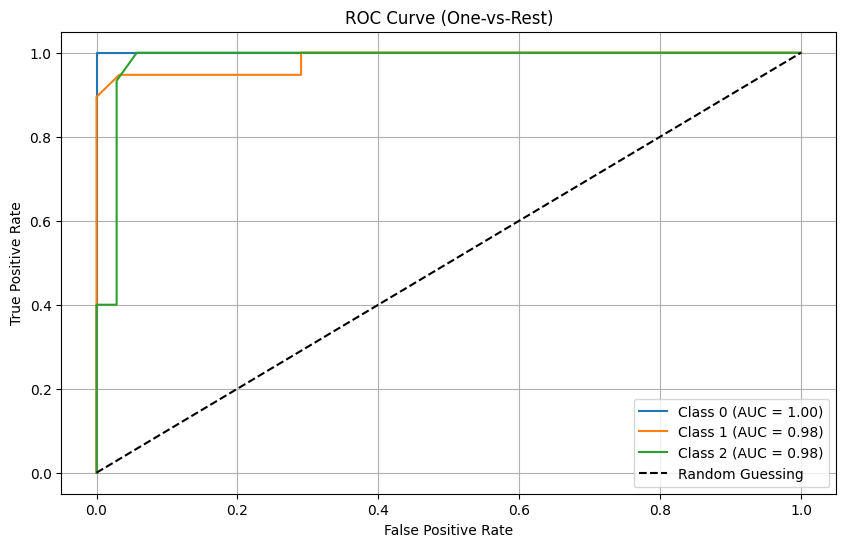

In [108]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Olasılık tahmini gerekir!
y_score = model.predict_proba(x_test)

# ROC çizimi
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Çizim
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend()
plt.grid()
plt.show()

ValueError: num must be an integer with 1 <= num <= 6, not 7

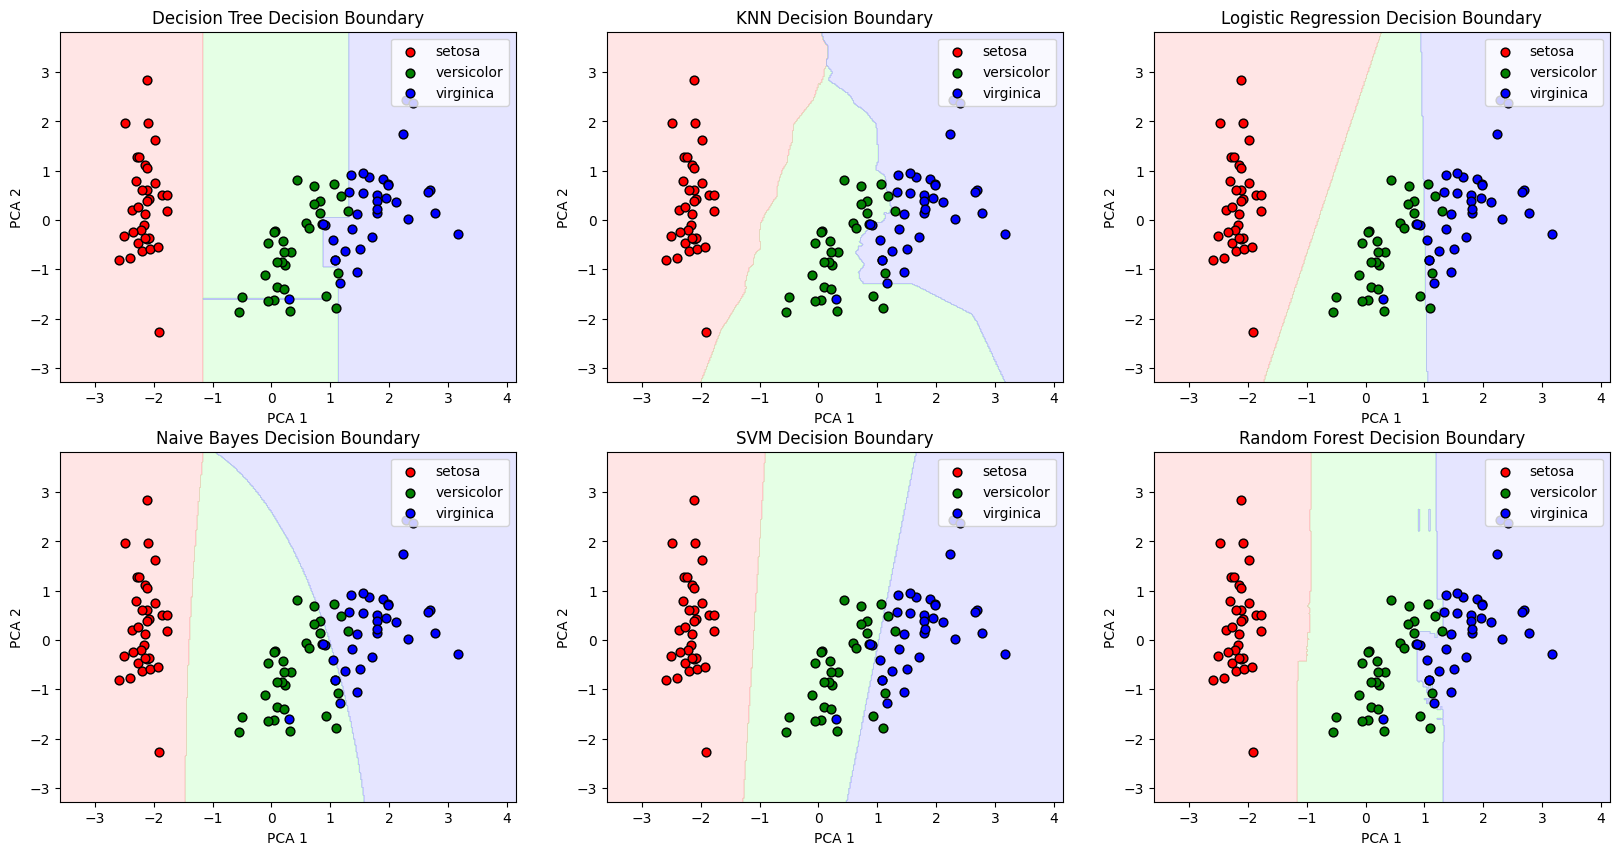

In [109]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# PCA ile 2 boyuta indir
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

# Karar sınırları için meshgrid oluştur
x_min, x_max = x_train_pca[:, 0].min() - 1, x_train_pca[:, 0].max() + 1
y_min, y_max = x_train_pca[:, 1].min() - 1, x_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Renk haritası
cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA", "#AAAAFF"])
cmap_bold = ["red", "green", "blue"]

# Tüm modeller için ayrı ayrı karar sınırı çiz
plt.figure(figsize=(20, 10))
for i, (name, model) in enumerate(models.items(), start=1):
    # Modeli yeniden PCA verisine göre eğit
    model.fit(x_train_pca, y_train)

    # Tüm alan için tahmin
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.subplot(2, 3, i)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

    # Gerçek eğitim verisini çiz
    for idx, color in enumerate(cmap_bold):
        plt.scatter(x_train_pca[y_train == idx, 0],
                    x_train_pca[y_train == idx, 1],
                    c=color, label=target_names[idx],
                    edgecolor='k', s=40)

    plt.title(f"{name} Decision Boundary")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()